In [26]:
# Deep Learning framework
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader, random_split
from torchsummary import summary

# Audio processing
import torchaudio
import torchaudio.transforms as T
import librosa

# Pre-trained image models
# import timm

# Play the audio in Jupyter notebook
from IPython.display import Audio
import pandas as pd
import os
import numpy as np

from scripts.dataset import AudioDataset
from scripts.get_dataframe import get_dataframe, get_balanced_dataframe
from models.cnn_tutorial import CNNNetworkTutorial

if torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(DEVICE)

cuda


In [2]:
class_mapping = ["positive", "negative"]

In [3]:
def train_single_epoch(model, dataloader, criterion, optimizer):
    for batch_idx, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model.forward(inputs)
        #outputs = model(inputs)

        # Compute the loss and its gradients
        loss = criterion(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

    return loss


def train(model, dataloader, criterion, optimizer, epochs, train_set):
    iteration_str_len = len(str(epochs))
    # loss sum of all batches of a single epoch
    loss_sum = 0
    for epoch in range(epochs):
        model.train()
        loss = train_single_epoch(model, dataloader, criterion, optimizer)

        # Collect sum of losses of each few epochs
        loss_sum += loss.item()

        # Printing information after every 10% of the total number of epochs
        if epoch % (epochs // 10) == 0:
            print(f"iteration {epoch: <{iteration_str_len}}: loss {loss.item()} | accuracy: {accuracy(model, train_set)}")
            print(f"average loss of the last {epochs // 10} epochs was: {loss_sum / (epochs // 10)}")
            # Reset loss_sum
            loss_sum = 0
            # Get model weights after each iteration
            model_weights = model.state_dict()
            #print("Model Weights:", model_weights)


def predict(model, input, target):
    model.eval()
    with torch.no_grad():
        predictions = model(input)
        # Tensor (1, 10) -> [ [0.1, 0.01, ..., 0.6] ]
        predicted_index = predictions[0].argmax(0)
        predicted = class_mapping[predicted_index]
        expected = class_mapping[target]
    return predicted, expected

def accuracy(model, dataset):
    correct = 0
    negative_predictions = 0
    total_samples = len(dataset)
    for idx in dataset.indices:
        input = dataset[dataset.indices.index(idx)][0].to(DEVICE)
        target = dataset[dataset.indices.index(idx)][1].argmax(0)
        input.unsqueeze_(0)

        predicted, expected = predict(model, input, target)
        #print(predicted, expected)
        if predicted == expected:
            correct += 1

        if predicted == "negative":
            negative_predictions += 1
    
    print((negative_predictions / total_samples) * 100, "negative predictions")
    return (correct / total_samples) * 100

In [4]:
AUDIO_DIR = "audios/labeled/"

dict_genres = {'positive': 0, 'negative': 1}


reverse_map = {v: k for k, v in dict_genres.items()}
print(reverse_map)

{0: 'positive', 1: 'negative'}


In [5]:
data = []

for label in dict_genres.keys():
    for folder in os.listdir(AUDIO_DIR + label):
        for file in os.listdir(AUDIO_DIR + label + "/" + folder):
            file_path = AUDIO_DIR + label + "/" + folder + "/" + file
            positive = int(label == "positive")
            negative = int(label == "negative")
            data.append((file_path, positive,
                        negative))

file_path, positive, negative = zip(*data)
df = pd.DataFrame({"file_path": file_path, "positive": positive, "negative": negative})

print(df.head(5))
print(f"Dataframe has {df.shape[0]} rows and {df.shape[1]} columns")

                                 file_path  positive  negative
0  audios/labeled/positive/1001/100101.wav         1         0
1  audios/labeled/positive/1001/100102.wav         1         0
2  audios/labeled/positive/1001/100103.wav         1         0
3  audios/labeled/positive/1001/100104.wav         1         0
4  audios/labeled/positive/1001/100105.wav         1         0
Dataframe has 236 rows and 3 columns


In [6]:
print(df.iloc[[1, 24]])
print(df.iloc[[5]])

                                  file_path  positive  negative
1   audios/labeled/positive/1001/100102.wav         1         0
24  audios/labeled/positive/1002/100217.wav         1         0
                                 file_path  positive  negative
5  audios/labeled/positive/1001/100106.wav         1         0


e:\anaconda3\envs\fourth_industrial_revolution\lib\site-packages\torchaudio\functional\functional.py:576: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


236
tensor([[[1.0973e+03, 5.4777e+02, 1.0136e+03,  ..., 6.7578e+02,
          8.6529e+02, 2.4509e+03],
         [1.0478e+03, 8.3276e+02, 6.8443e+02,  ..., 1.2473e+03,
          1.2999e+03, 1.4261e+03],
         [2.9249e+03, 1.2258e+03, 6.7735e+02,  ..., 6.8507e+02,
          5.1316e+02, 2.3577e+02],
         ...,
         [4.3693e-01, 1.0924e-01, 1.5686e-06,  ..., 4.2437e-07,
          3.3894e-01, 1.6692e+00],
         [5.4774e-01, 1.3694e-01, 1.1247e-06,  ..., 7.2866e-08,
          3.4464e-01, 1.6973e+00],
         [9.8952e-01, 2.4741e-01, 2.0624e-06,  ..., 1.5790e-08,
          3.5482e-01, 1.7474e+00]]])
tensor([[[1.0973e+03, 5.4777e+02, 1.0136e+03,  ..., 6.7578e+02,
          8.6529e+02, 2.4509e+03],
         [1.0478e+03, 8.3276e+02, 6.8443e+02,  ..., 1.2473e+03,
          1.2999e+03, 1.4261e+03],
         [2.9249e+03, 1.2258e+03, 6.7735e+02,  ..., 6.8507e+02,
          5.1316e+02, 2.3577e+02],
         ...,
         [4.3693e-01, 1.0924e-01, 1.5686e-06,  ..., 4.2437e-07,
          3

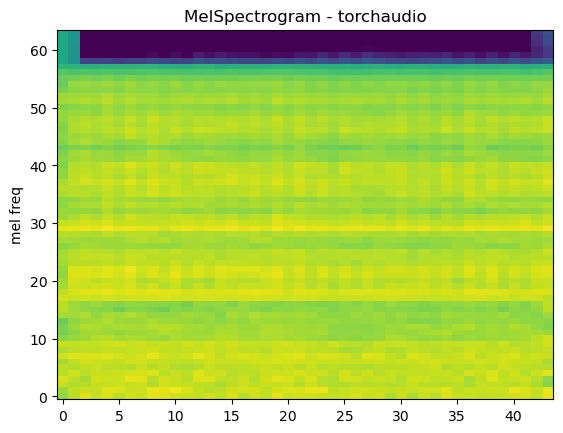

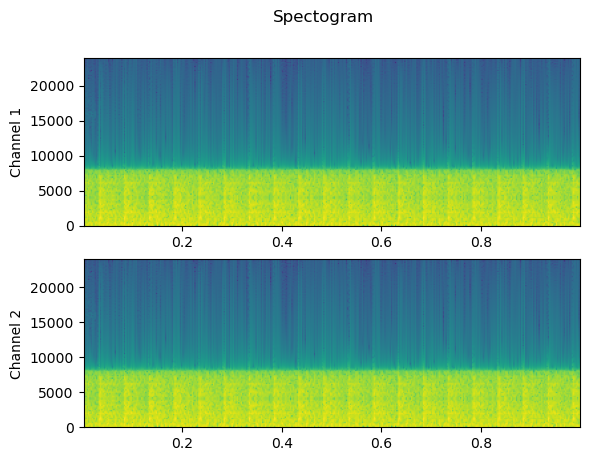

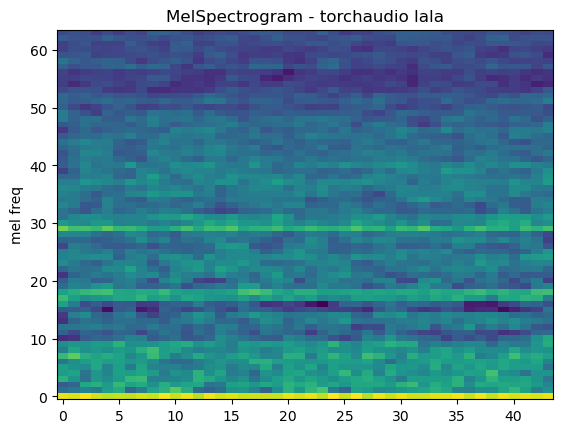

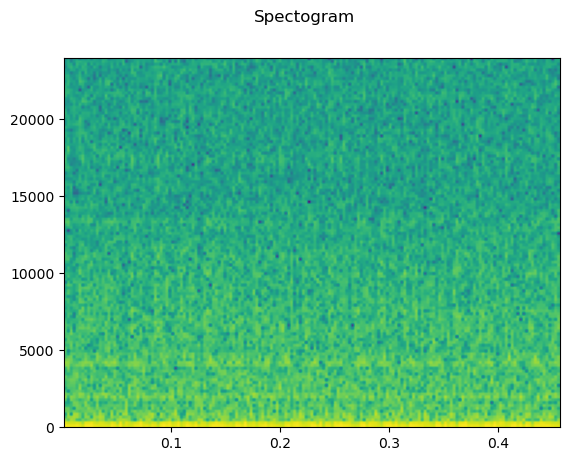

e:\anaconda3\envs\fourth_industrial_revolution\lib\site-packages\torchaudio\functional\functional.py:576: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


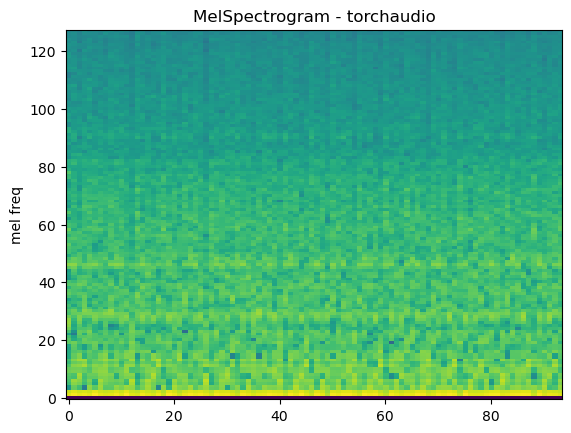

torch.Size([128, 94])


In [35]:
BATCH_SIZE = 1
EPOCHS = 100
LEARNING_RATE = 0.0003
SAVE = False
TRAIN_RATIO = 0.8
l2_lambda = 0.01

df = get_dataframe()

# comments are about first melspectogram !!!
# 1 (positive) has 4 round blue circles in the yellow/green area + things on the side at the top in the blue/purple area
# 5 (positive) has things on the side at the top in the blue/purple area
# 10 (positive) has 4 round yellow circles in the yellow/green area + things on the side at the top in the blue/purple area
# 24 (negative) has 4 round blue circles in the yellow/green area + things on the side at the top in the blue/purple area
# WHY DO 1 AND 24 LOOK SIMILAR ?????????????? (first sample has index 0)
num_of_audio_sample = 1

dataset = AudioDataset(df, melspectrogram_to_mfcc=False, convert_amplitude_to_db=False)

# Tests
#------------------------------------------------------------------------------------
print(AudioDataset.__len__(dataset))
print(AudioDataset.__getitem__(dataset,0)[0])
print(AudioDataset.__getitem__(dataset,0)[0])
print(AudioDataset.__getitem__(dataset,0)[0].size())
print(AudioDataset.__getitem__(dataset,0)[1])
print(AudioDataset.__getitem__(dataset,0)[1].size())
print(AudioDataset.__getitem__(dataset,0)[0][:, :, 0])
print(AudioDataset.__getitem__(dataset,0)[0][0].size())
print(AudioDataset.__getitem__(dataset, num_of_audio_sample)[0][0])

import matplotlib.pyplot as plt

def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")
    plt.show(block=False)
    
plot_spectrogram(AudioDataset.__getitem__(dataset, num_of_audio_sample)[0][0], title="MelSpectrogram - torchaudio", ylabel="mel freq")

# df.iat[1, 0] is the second audio-path in the dataframe
audio, sample_rate = torchaudio.load(df.iat[num_of_audio_sample, 0])

def plot_specgram(waveform, sample_rate, title="Spectrogram"):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].specgram(waveform[c], Fs=sample_rate)
        if num_channels > 1:
            axes[c].set_ylabel(f"Channel {c+1}")
    figure.suptitle(title)
    plt.show(block=False)

plot_specgram(audio, sample_rate, title="Spectogram")


# Test functions from dataset.py here:
#-------------------------------------
if sample_rate != 22050: #_resample
    resampler = T.Resample(sample_rate, 22050)
    audio = resampler(audio)

audio = torch.mean(audio, dim=0, keepdim=True) #_mono

# WHYYYYYYYYY ARE WE CUTTING THE AUDIO DATA AND ON WHAT MEASURE???
if audio.shape[1] > 22050: #_crop 
    audio = audio[:, :22050]

audio_length = audio.shape[1] #_right_pad
if audio_length < 22050:
    num_missing_samples = 22050 - audio_length
    last_dim_padding = (0, num_missing_samples)
    audio = F.pad(audio, last_dim_padding)

melspectrogram = T.MelSpectrogram(sample_rate=22050,
                                               n_mels=64,
                                               n_fft=2048,
                                               hop_length=512)#.to(DEVICE) 
amplitude_to_db = T.AmplitudeToDB()
audio = amplitude_to_db(audio)
melspec = melspectrogram(audio)
plot_spectrogram(melspec[0], title="MelSpectrogram - torchaudio lala", ylabel="mel freq")   

plot_specgram(audio, sample_rate, title="Spectogram")   
#------------------------------------------------------------------------------------

audio, sample_rate = torchaudio.load(df.iat[num_of_audio_sample, 0])

n_fft = 1024
win_length = None
hop_length = 512
n_mels = 128

mel_spectrogram = T.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=n_fft,
    win_length=win_length,
    hop_length=hop_length,
    center=True,
    pad_mode="reflect",
    power=2.0,
    norm="slaney",
    n_mels=n_mels,
    mel_scale="htk",
)

amplitude_to_db = torchaudio.transforms.AmplitudeToDB()
audio_amplitude_to_db = amplitude_to_db(audio)
melspec = mel_spectrogram(audio_amplitude_to_db)

plot_spectrogram(melspec[0], title="MelSpectrogram - torchaudio", ylabel="mel freq")
print(melspec[0].size())

In [7]:
BATCH_SIZE = 1
EPOCHS = 100
LEARNING_RATE = 0.0003
SAVE = False
TRAIN_RATIO = 0.8
TEST_RATIO = 1 - TRAIN_RATIO
l2_lambda = 0.01

# Setting random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

df = get_balanced_dataframe()

dataset = AudioDataset(df, melspectrogram_to_mfcc=True, convert_amplitude_to_db=True)

# Calculate the lengths of training and testing subsets
train_length = int(len(dataset) * TRAIN_RATIO)

# Use random_split to split the dataset
train_set, validation_set = random_split(dataset, [train_length, len(dataset) - train_length])
print("train:", len(train_set))
print("validation:", len(validation_set))
# Create data loaders for training and testing
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_set, batch_size=BATCH_SIZE, shuffle=False)

# construct model and assign it to device
model = CNNNetworkTutorial().to(DEVICE)
#summary(model.cuda(), (1, 64, 44))

# initialise loss funtion + optimiser
criterion = nn.BCELoss()
# criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                                lr=LEARNING_RATE,
                                weight_decay=l2_lambda)

# train model
train(model, train_loader, criterion, optimizer, EPOCHS, train_set)

print("Train Set Accuracy: ", accuracy(model, train_set),"%")
print("Validation Set Accuracy: ", accuracy(model, validation_set),"%")

# save model
if SAVE:
    torch.save(model.state_dict(), "cnn_tutorial.pth")
    print("Saved as cnn_tutorial.pth")

e:\anaconda3\envs\fourth_industrial_revolution\lib\site-packages\torchaudio\functional\functional.py:576: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


train: 289
validation: 73
100.0 negative predictions
iteration 0  : loss 0.6246641278266907 | accuracy: 50.51903114186851
average loss of the last 10 epochs was: 0.06246641278266907
6.5743944636678195 negative predictions
iteration 10 : loss 0.8209109902381897 | accuracy: 56.05536332179931
average loss of the last 10 epochs was: 0.7248543798923492
27.33564013840831 negative predictions
iteration 20 : loss 0.4072742760181427 | accuracy: 74.74048442906575
average loss of the last 10 epochs was: 0.5484559591859579
59.16955017301038 negative predictions
iteration 30 : loss 0.33946239948272705 | accuracy: 85.12110726643598
average loss of the last 10 epochs was: 0.44954966735094787
52.94117647058824 negative predictions
iteration 40 : loss 0.2805595397949219 | accuracy: 89.96539792387543
average loss of the last 10 epochs was: 0.2175037236418575
48.44290657439446 negative predictions
iteration 50 : loss 0.048233069479465485 | accuracy: 93.77162629757785
average loss of the last 10 epochs wa

In [5]:
input, target = dataset[10][0].to(DEVICE), dataset[10][1].argmax(0)
input.unsqueeze_(0)


predicted, expected = predict(model, input, target)
print(f"Predicted: '{predicted}', expected: '{expected}'")

Predicted: 'positive', expected: 'positive'
